<a href="https://colab.research.google.com/github/kaoutharelazzab/smart-heart-tracker/blob/main/Untitled9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

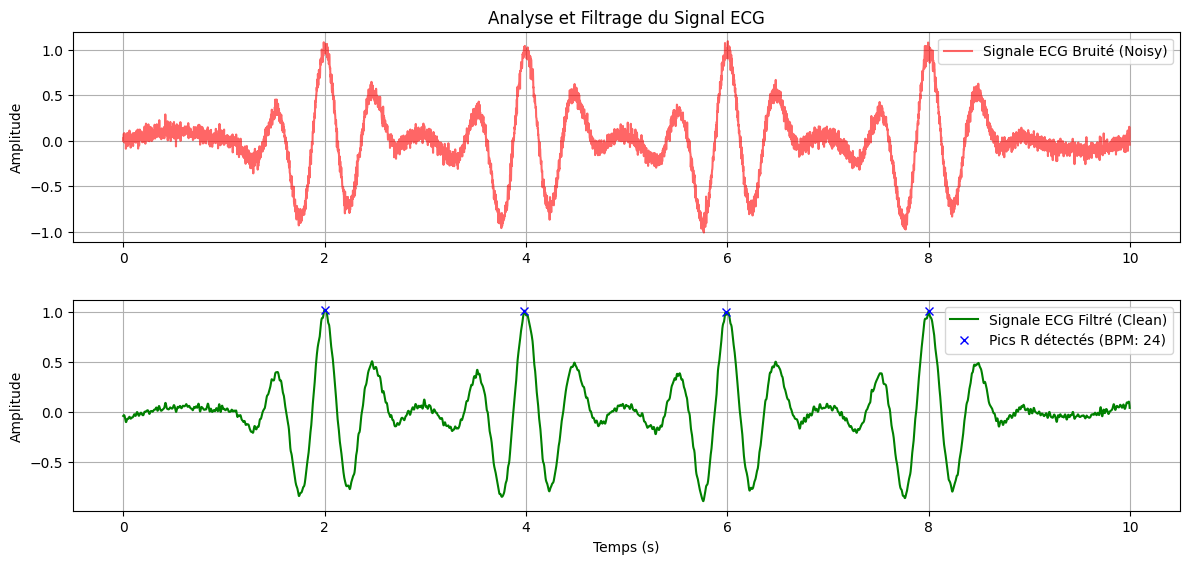

📊 معدل ضربات القلب المحسوب (Heart Rate): 24 نبضة في الدقيقة (BPM)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. توليد إشارة تخطيط قلب (ECG) افتراضية مع إضافة تشويش
np.random.seed(42)
fs = 500  # تردد العينات (Sampling frequency)
time = np.linspace(0, 10, 10 * fs, endpoint=False)

# توليد النبضات الأساسية للإشارة
ecg_clean = signal.gausspulse(time - 2, fc=2) + signal.gausspulse(time - 4, fc=2) + \
            signal.gausspulse(time - 6, fc=2) + signal.gausspulse(time - 8, fc=2)

# إضافة تشويش عالي التردد (High-frequency noise) وتشويش خط الأساس (Baseline wander)
noise = 0.05 * np.random.normal(size=len(time)) + 0.1 * np.sin(2 * np.repeat(np.pi, len(time)) * 0.5 * time)
ecg_noisy = ecg_clean + noise

# 2. تصميم فلتر رقمي (Digital Filter) لتصفية الإشارة
# سنستخدم فلتر تمرير حزامي (Bandpass Filter) بين 0.5 و 40 هرتز لتنقية إشارة القلب
b, a = signal.butter(3, [0.5 / (fs / 2), 40 / (fs / 2)], btype='bandpass')
ecg_filtered = signal.filtfilt(b, a, ecg_noisy)

# 3. خوارزمية بسيطة لتحديد قمم النبضات (R-peaks) وحساب معدل ضربات القلب
peaks, _ = signal.find_peaks(ecg_filtered, distance=fs*0.6, height=0.3)
bpm = len(peaks) * 6  # حساب عدد النبضات في الدقيقة (على أساس 10 ثوانٍ من الإشارة)

# 4. رسم النتائج بيانيًا لمقارنة الإشارات
plt.figure(figsize=(12, 8))

# رسم الإشارة المشوشة الأصلية
plt.subplot(3, 1, 1)
plt.plot(time, ecg_noisy, color='red', alpha=0.6, label='Signale ECG Bruité (Noisy)')
plt.title('Analyse et Filtrage du Signal ECG')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# رسم الإشارة بعد التصفية والتنقية
plt.subplot(3, 1, 2)
plt.plot(time, ecg_filtered, color='green', label='Signale ECG Filtré (Clean)')
plt.plot(time[peaks], ecg_filtered[peaks], "x", color='blue', label=f'Pics R détectés (BPM: {bpm})')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.xlabel('Temps (s)')
plt.tight_layout()
plt.show()

print(f"📊 معدل ضربات القلب المحسوب (Heart Rate): {bpm} نبضة في الدقيقة (BPM)")